In [ ]:
import tskit
import numpy as np
import functions as func

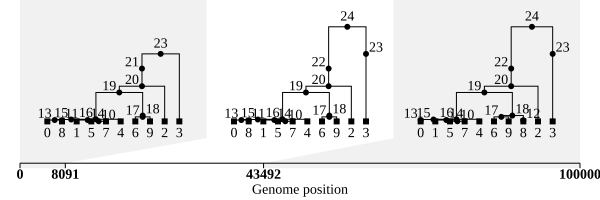

In [ ]:
#test = msprime.sim_ancestry(3, recombination_rate=0.1, sequence_length=2, record_full_arg=True, random_seed=42)
#msprime.sim_ancestry(5, sequence_length=1e5, recombination_rate=1e-6, record_full_arg=True)

#simp_test = test.simplify()
#ext_test = simp_test.extend_haplotypes()

ts = tskit.load("/home/islar/bradburdlab/tree_project/unary_project/tree-S0.8-R0.trees")

tsimp = ts.simplify()
tsext = tsimp.extend_haplotypes()
sigma = 0.8
rep = 0
#test.draw_svg()

unary_indices_big = func.findUnary(tsext)
func.big_getAccOut(tsext, unary_indices_big, "S0.8-R0_ext", sigma, rep)
func.big_getAccOut(tsimp, unary_indices_big, "S0.8-R0_simp", sigma, rep)



In [ ]:
def example1():
        node_times = {
            0: 0,
            1: 0,
            2: 0,
            3: 0,
            4: 1,
            5: 1,
            6: 4,
            7: 6,
            8: 10,
            9: 4,
            10: 12,
            11: 8,
            12: 8,
            13: 15,
        }
        # (p,c,l,r)
        edges = [
            (4, 0, 0, 9),
            (4, 1, 0, 9),
            (5, 2, 0, 6),
            (5, 3, 0, 9),
            (6, 4, 0, 3),
            (9, 5, 0, 3),
            (7, 4, 3, 6),
            (11, 7, 3, 6),
            (12, 5, 3, 6),
            (8, 2, 6, 9),
            (8, 4, 6, 9),
            (8, 6, 0, 3),
            (10, 5, 6, 9),
            (10, 8, 0, 3),
            (10, 8, 6, 9),
            (10, 9, 0, 3),
            (10, 11, 3, 6),
            (10, 12, 3, 6),
            (13, 10, 3, 6),
        ]
        extended_edges = [
            (4, 0, 0.0, 9.0),
            (4, 1, 0.0, 9.0),
            (5, 2, 0.0, 6.0),
            (5, 3, 0.0, 9.0),
            (6, 4, 0.0, 9.0),
            (9, 5, 0.0, 9.0),
            (7, 6, 0.0, 9.0),
            (11, 7, 0.0, 9.0),
            (12, 9, 0.0, 9.0),
            (8, 2, 6.0, 9.0),
            (8, 11, 0.0, 9.0),
            (10, 8, 0.0, 9.0),
            (10, 12, 0.0, 9.0),
            (13, 10, 3.0, 6.0),
        ]
        samples = list(np.arange(4))
        tables = tskit.TableCollection(sequence_length=9)
        for (
            n,
            t,
        ) in node_times.items():
            flags = tskit.NODE_IS_SAMPLE if n in samples else 0
            tables.nodes.add_row(time=t, flags=flags)
        for p, c, l, r in edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ts = tables.tree_sequence()
        tables.edges.clear()
        for p, c, l, r in extended_edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ets = tables.tree_sequence()
        assert ts.num_edges == 19
        assert ets.num_edges == 14
        return ts, ets

t1, et1 = example1()

samples1 = np.array([
    [0, 11.3, 2.6],  # node 0 at coordinates (1.5, 2.0)
    [1, 17.5, 12.4],  # node 1 at coordinates (4.2, 3.1) 
    [2, 16.7, 15.6],  # node 2 at coordinates (6.7, 5.5)
    [3, 14.5, 12.9],  # node 2 at coordinates (6.7, 5.5)
])

ancestors1 = np.array([
    [4, 19.8, 13.4],  # node 2 at coordinates (6.7, 5.5)
    [5, 18.5, 19.3],  # node 2 at coordinates (6.7, 5.5)
    [6, 17.9, 18.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 21.1, 12.1],  # node 1 at coordinates (4.2, 3.1) 
    [8, 17.2, 17.2],  # node 2 at coordinates (6.7, 5.5)
    [9, 13.9, 12.1],  # node 2 at coordinates (6.7, 5.5)
    [10, 17.7, 17.7],  # node 2 at coordinates (6.7, 5.5)
    [11, 20.1, 20.6],  # node 2 at coordinates (6.7, 5.5)
    [12, 19.2, 15.5],  # node 2 at coordinates (6.7, 5.5)
    [13, 15.4, 17.8],  # node 2 at coordinates (6.7, 5.5)
])

everything1 = np.array([
    [0, 11.3, 2.6],  # node 0 at coordinates (1.5, 2.0)
    [1, 17.5, 12.4],  # node 1 at coordinates (4.2, 3.1) 
    [2, 16.7, 15.6],  # node 2 at coordinates (6.7, 5.5)
    [3, 14.5, 12.9],  # node 2 at coordinates (6.7, 5.5)
    [4, 19.8, 13.4],  # node 2 at coordinates (6.7, 5.5)
    [5, 18.5, 19.3],  # node 2 at coordinates (6.7, 5.5)
    [6, 17.9, 18.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 21.1, 12.1],  # node 1 at coordinates (4.2, 3.1) 
    [8, 17.2, 17.2],  # node 2 at coordinates (6.7, 5.5)
    [9, 13.9, 12.1],  # node 2 at coordinates (6.7, 5.5)
    [10, 17.7, 17.7],  # node 2 at coordinates (6.7, 5.5)
    [11, 20.1, 20.6],  # node 2 at coordinates (6.7, 5.5)
    [12, 19.2, 15.5],  # node 2 at coordinates (6.7, 5.5)
    [13, 15.4, 17.8],  # node 2 at coordinates (6.7, 5.5)
])

unary_indices1 = func.findUnary(et1)
func.small_getAccOut(t1, unary_indices1, samples1, ancestors1, everything1, "test1_simp")
func.small_getAccOut(et1, unary_indices1, samples1, ancestors1, everything1, "test1_ext")



NameError: name 'findUnary' is not defined

In [ ]:
def example2():
        node_times = {
            0: 0,
            1: 0,
            2: 0,
            3: 0,
            4: 0,
            5: 0,
            6: 0,
            7: 0,
            8: 0,
            9: 0,
            10: 1,
            11: 2,
            12: 3,
            13: 4,
            14: 5,
            15: 6,
            16: 7,
            17: 8,
            18: 9,
            19: 10,
            20: 11,
            21: 12,
        }
        # (p,c,l,r)
        edges = [
            (10, 2, 0, 9),
            (10, 5, 0, 9),
            (11, 0, 0, 9),
            (11, 7, 0, 9),
            (12, 3, 3, 9),
            (12, 9, 3, 9),
            (13, 4, 0, 9),
            (13, 11, 0, 9),
            (14, 6, 0, 9),
            (14, 10, 0, 9),
            (15, 9, 0, 3),
            (15, 13, 0, 3),
            (16, 1, 0, 6),
            (16, 3, 0, 3),
            (16, 12, 3, 6),
            (17, 1, 6, 9),
            (17, 13, 6, 9),
            (18, 13, 3, 6),
            (18, 14, 0, 9),
            (18, 15, 0, 3),
            (18, 17, 6, 9),
            (19, 8, 0, 9),
            (19, 12, 6, 9),
            (19, 16, 0, 6),
            (20, 18, 0, 3),
            (20, 18, 6, 9),
            (20, 19, 0, 3),
            (20, 19, 6, 9),
            (21, 18, 3, 6),
            (21, 19, 3, 6),
        ]
        extended_edges = [
            (10, 2, 0.0, 9.0),
            (10, 5, 0.0, 9.0),
            (11, 0, 0.0, 9.0),
            (11, 7, 0.0, 9.0),
            (12, 3, 0.0, 9.0),
            (12, 9, 3.0, 9.0),
            (13, 4, 0.0, 9.0),
            (13, 11, 0.0, 9.0),
            (14, 6, 0.0, 9.0),
            (14, 10, 0.0, 9.0),
            (15, 9, 0.0, 3.0),
            (15, 13, 0.0, 9.0),
            (16, 1, 0.0, 6.0),
            (16, 12, 0.0, 9.0),
            (17, 1, 6.0, 9.0),
            (17, 15, 0.0, 9.0),
            (18, 14, 0.0, 9.0),
            (18, 17, 0.0, 9.0),
            (19, 8, 0.0, 9.0),
            (19, 16, 0.0, 9.0),
            (20, 18, 0.0, 3.0),
            (20, 18, 6.0, 9.0),
            (20, 19, 0.0, 3.0),
            (20, 19, 6.0, 9.0),
            (21, 18, 3.0, 6.0),
            (21, 19, 3.0, 6.0),
        ]
        samples = list(np.arange(10))
        tables = tskit.TableCollection(sequence_length=9)
        for (
            n,
            t,
        ) in node_times.items():
            flags = tskit.NODE_IS_SAMPLE if n in samples else 0
            tables.nodes.add_row(time=t, flags=flags)
        for p, c, l, r in edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ts = tables.tree_sequence()
        tables.edges.clear()
        for p, c, l, r in extended_edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ets = tables.tree_sequence()
        assert ts.num_edges == 30
        assert ets.num_edges == 26
        return ts, ets

t2, et2 = example2()

samples2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5) 
    [4, 9.0, 10.5],  # node 2 at coordinates (6.7, 5.5) 
    [5, 11.3, 2.5],  # node 2 at coordinates (6.7, 5.5) 
    [6, 11.2, 5.4],  # node 2 at coordinates (6.7, 5.5) 
    [7, 12.0, 6.9],  # node 2 at coordinates (6.7, 5.5) 
    [8, 11.1, 4.7],  # node 2 at coordinates (6.7, 5.5) 
    [9, 1.6, 2.0],  # node 0 at coordinates (1.5, 2.0) 
])

ancestors2 = np.array([
    [10, 2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [11, 3.6, 5.2],  # node 0 at coordinates (1.5, 2.0)
    [12, 4.1, 7.8],  # node 0 at coordinates (1.5, 2.0)
    [13, 7.8, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [14, 5.6, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [15, 9.7, 3.1],  # node 0 at coordinates (1.5, 2.0)
    [16, 9.8, 11.1],  # node 0 at coordinates (1.5, 2.0)
    [17, 10.1, 11.6],  # node 0 at coordinates (1.5, 2.0)
    [18, 11.2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [19, 14.1, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [20, 1.2, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [21, 4.3, 8.7],  # node 0 at coordinates (1.5, 2.0)
])

everything2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5) 
    [4, 9.0, 10.5],  # node 2 at coordinates (6.7, 5.5) 
    [5, 11.3, 2.5],  # node 2 at coordinates (6.7, 5.5) 
    [6, 11.2, 5.4],  # node 2 at coordinates (6.7, 5.5) 
    [7, 12.0, 6.9],  # node 2 at coordinates (6.7, 5.5) 
    [8, 11.1, 4.7],  # node 2 at coordinates (6.7, 5.5) 
    [9, 1.6, 2.0],  # node 0 at coordinates (1.5, 2.0) 
    [10, 2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [11, 3.6, 5.2],  # node 0 at coordinates (1.5, 2.0)
    [12, 4.1, 7.8],  # node 0 at coordinates (1.5, 2.0)
    [13, 7.8, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [14, 5.6, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [15, 9.7, 3.1],  # node 0 at coordinates (1.5, 2.0)
    [16, 9.8, 11.1],  # node 0 at coordinates (1.5, 2.0)
    [17, 10.1, 11.6],  # node 0 at coordinates (1.5, 2.0)
    [18, 11.2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [19, 14.1, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [20, 1.2, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [21, 4.3, 8.7],  # node 0 at coordinates (1.5, 2.0)
])

unary_indices2 = func.findUnary(et2)
func.small_getAccOut(t2, unary_indices2, samples2, ancestors2, everything2, "test2_simp")
func.small_getAccOut(et2, unary_indices2, samples2, ancestors2, everything2, "test2_ext")

,sigma,rep,node_id,node_time,error,dist_from_sample_centroid0,dist_from_sample_centroid
0,0.2,0,12.0,3.0,0.119746,4.550275,2.297666
1,0.2,0,15.0,6.0,0.509990,2.762788,1.199327
2,0.2,0,16.0,7.0,0.642642,6.687077,1.424632
3,0.2,0,17.0,8.0,0.573724,7.260096,0.443333


In [ ]:
def example4():        
    node_times = (0, 0, 0, 0, 1, 1, 3, 2, 2)
    samples = (0, 1, 2, 3)
    # (p, c, l, r)
    extended_edges = [
        (4, 0, 0, 10),
        (4, 1, 0, 5),
        (4, 1, 7, 10),
        (5, 2, 0, 2),
        (5, 2, 5, 10),
        (5, 3, 0, 10),
        (7, 2, 2, 5),
        (7, 4, 0, 10),
        (8, 1, 5, 7),
        (8, 5, 0, 10),
        (6, 7, 0, 10),
        (6, 8, 0, 10),
    ]
    edges = [
        (4, 0, 0, 10),
        (4, 1, 0, 5),
        (4, 1, 7, 10),
        (5, 2, 0, 2),
        (5, 2, 5, 10),
        (5, 3, 0, 2),
        (5, 3, 5, 10),
        (7, 2, 2, 5),
        (7, 4, 2, 5),
        (8, 1, 5, 7),
        (8, 5, 5, 7),
        (6, 3, 2, 5),
        (6, 4, 0, 2),
        (6, 4, 5, 10),
        (6, 5, 0, 2),
        (6, 5, 7, 10),
        (6, 7, 2, 5),
        (6, 8, 5, 7),
    ]
    tables = tskit.TableCollection(sequence_length=10)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 18
    assert ets.num_edges == 12
    return ts, ets

t4, et4 = example4()

samples4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors4 = np.array([
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [6, 2, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 4.1, 3.9],  # node 1 at coordinates (4.2, 3.1) 
    [8, 6.0, 5.4],  # node 2 at coordinates (6.7, 5.5)
 ])

everything4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [6, 2, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 4.1, 3.9],  # node 1 at coordinates (4.2, 3.1) 
    [8, 6.0, 5.4],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = func.findUnary(et4)
# func.small_getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# func.small_getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")


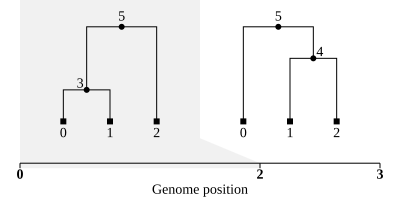

In [ ]:
def attempt1():
    node_times = (0, 0, 0, 1, 2, 3)
    samples = (0, 1, 2)
    # (p, c, l, r)
    extended_edges = [
        (3, 0, 0, 4),
        (3, 1, 0, 3), 
        (4, 1, 3, 4),
        (4, 2, 0, 4), 
        (5, 3, 0, 4), 
        (5, 4, 0, 4),
    ]
    edges = [
        (3, 0, 0, 3),
        (3, 1, 0, 3), 
        (4, 1, 3, 4),
        (4, 2, 3, 4), 
        (5, 0, 3, 4),
        (5, 2, 0, 3), 
        (5, 3, 0, 3), 
        (5, 4, 3, 4),
    ]
    tables = tskit.TableCollection(sequence_length=4)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 8
    assert ets.num_edges == 6
    return ts, ets

sattempt1, extattempt1 = attempt1()
samples_attempt1 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors_attempt1 = np.array([
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
 ])

everything_attempt1 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")
unary_indices_attempt1 = func.findUnary(extattempt1)
func.small_getAccOut(extattempt1, unary_indices_attempt1, samples_attempt1, ancestors_attempt1, everything_attempt1, "attempt1")
sext1 = sattempt1.extend_haplotypes()
sattempt1.draw_svg()

In [ ]:
def attempt2():
    node_times = (0, 0, 0, 1, 2, 3)
    samples = (0, 1, 2)
    # (p, c, l, r)
    extended_edges = [
        (3, 0, 0, 3),
        (3, 1, 0, 2), 
        (4, 1, 2, 3),
        (4, 2, 0, 3), 
        (5, 3, 0, 3), 
        (5, 4, 0, 3),
    ]
    edges = [
        (3, 0, 0, 2),
        (3, 1, 0, 2), 
        (4, 1, 2, 3),
        (4, 2, 2, 3), 
        (5, 0, 2, 3),
        (5, 2, 0, 2), 
        (5, 3, 0, 2), 
        (5, 4, 2, 3),
    ]
    tables = tskit.TableCollection(sequence_length=3)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 8
    assert ets.num_edges == 6
    return ts, ets

sattempt2, extattempt2 = attempt2()
samples_attempt2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors_attempt2 = np.array([
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
 ])

everything_attempt2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")
unary_indices_attempt2 = func.findUnary(extattempt2)
func.small_getAccOut(extattempt2, unary_indices_attempt2, samples_attempt2, ancestors_attempt2, everything_attempt2, "attempt2_ext")
func.small_getAccOut(sattempt2, unary_indices_attempt2, samples_attempt2, ancestors_attempt2, everything_attempt2, "attempt2_simp")
sext2 = sattempt2.extend_haplotypes()
sattempt2.draw_svg()

In [ ]:
def attempt3():
    node_times = (0, 0, 0, 1, 2, 3)
    samples = (0, 1, 2)
    # (p, c, l, r)
    extended_edges = [
        (3, 0, 0, 10),
        (3, 1, 0, 9), 
        (4, 1, 9, 10),
        (4, 2, 0, 10), 
        (5, 3, 0, 10), 
        (5, 4, 0, 10),
    ]
    edges = [
        (3, 0, 0, 9),
        (3, 1, 0, 9), 
        (4, 1, 9, 10),
        (4, 2, 9, 10), 
        (5, 0, 9, 10),
        (5, 2, 0, 9), 
        (5, 3, 0, 9), 
        (5, 4, 9, 10),
    ]
    tables = tskit.TableCollection(sequence_length=10)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 8
    assert ets.num_edges == 6
    return ts, ets

sattempt3, extattempt3 = attempt3()
samples_attempt3 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors_attempt3 = np.array([
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
 ])

everything_attempt3 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")
unary_indices_attempt3 = func.findUnary(extattempt3)
func.small_getAccOut(extattempt3, unary_indices_attempt3, samples_attempt3, ancestors_attempt3, everything_attempt3, "attempt3_ext")
func.small_getAccOut(sattempt3, unary_indices_attempt3, samples_attempt3, ancestors_attempt3, everything_attempt3, "attempt3_simp")
sext3 = sattempt3.extend_haplotypes()
sattempt3.draw_svg()

In [ ]:
def attempt4():
    node_times = (0, 0, 0, 1, 2, 3)
    samples = (0, 1, 2)
    # (p, c, l, r)
    extended_edges = [
        (3, 0, 0, 30),
        (3, 1, 0, 29), 
        (4, 1, 29, 30),
        (4, 2, 0, 30), 
        (5, 3, 0, 30), 
        (5, 4, 0, 30),
    ]
    edges = [
        (3, 0, 0, 29),
        (3, 1, 0, 29), 
        (4, 1, 29, 30),
        (4, 2, 29, 30), 
        (5, 0, 29, 30),
        (5, 2, 0, 29), 
        (5, 3, 0, 29), 
        (5, 4, 29, 30),
    ]
    tables = tskit.TableCollection(sequence_length=30)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 8
    assert ets.num_edges == 6
    return ts, ets

sattempt4, extattempt4 = attempt4()
samples_attempt4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors_attempt4 = np.array([
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
 ])

everything_attempt4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")
unary_indices_attempt4 = func.findUnary(extattempt4)
func.small_getAccOut(extattempt4, unary_indices_attempt4, samples_attempt4, ancestors_attempt4, everything_attempt4, "attempt4_ext")
func.small_getAccOut(sattempt4, unary_indices_attempt4, samples_attempt4, ancestors_attempt4, everything_attempt4, "attempt4_simp")
sattempt4.draw_svg()

In [ ]:
#test = msprime.sim_ancestry(3, recombination_rate=0.1, sequence_length=2, record_full_arg=True, random_seed=42)